In [ ]:
# Product Analysis
Identifying top revenue products, worst performers, and highest return rates
from 541K transactions across 4,000+ unique products.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load full dataset — we need cancellations too for return rate analysis
df_all = pd.read_csv('../data/online_retail.csv', encoding='latin-1')
df_all['InvoiceDate'] = pd.to_datetime(df_all['InvoiceDate'])

# Clean version — for revenue analysis
df = df_all.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Clean sales data: {df.shape[0]:,} rows")
print(f"Unique products:  {df['StockCode'].nunique():,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")

Clean sales data: 397,884 rows
Unique products:  3,665
Unique customers: 4,338


In [2]:
product_revenue = (
    df.groupby(['StockCode', 'Description'])
    .agg(
        Total_Revenue = ('Revenue',     'sum'),
        Total_Quantity = ('Quantity',   'sum'),
        Num_Orders    = ('InvoiceNo',   'nunique')
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)

top10 = product_revenue.head(10)
print("Top 10 products by revenue:")
print(top10[['Description','Total_Revenue','Total_Quantity','Num_Orders']].to_string(index=False))

Top 10 products by revenue:
                       Description  Total_Revenue  Total_Quantity  Num_Orders
       PAPER CRAFT , LITTLE BIRDIE      168469.60           80995           1
          REGENCY CAKESTAND 3 TIER      142592.95           12402        1703
WHITE HANGING HEART T-LIGHT HOLDER      100448.15           36725        1971
           JUMBO BAG RED RETROSPOT       85220.78           46181        1600
    MEDIUM CERAMIC TOP STORAGE JAR       81416.73           77916         195
                           POSTAGE       77803.96            3120        1099
                     PARTY BUNTING       68844.33           15291        1379
     ASSORTED COLOUR BIRD ORNAMENT       56580.34           35362        1375
                            Manual       53779.93            7173         253
                RABBIT NIGHT LIGHT       51346.20           27202         801


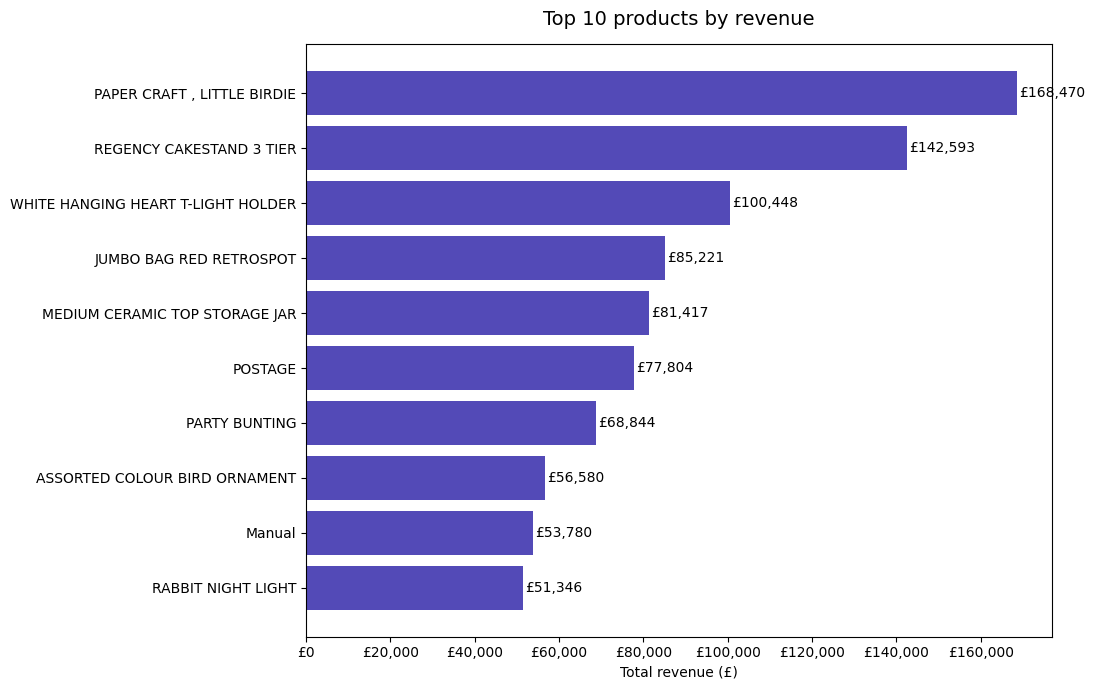

Chart saved!


In [3]:
fig, ax = plt.subplots(figsize=(11, 7))

# Shorten long descriptions for chart
labels = [d[:40] + '...' if len(d) > 40 else d
          for d in top10['Description']]

bars = ax.barh(labels[::-1], top10['Total_Revenue'][::-1],
               color='#534AB7', edgecolor='none')

ax.set_title('Top 10 products by revenue', fontsize=14, pad=14)
ax.set_xlabel('Total revenue (£)')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

for bar, val in zip(bars, top10['Total_Revenue'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [4]:
# Cancelled orders — negative quantities, InvoiceNo starts with C
cancelled = df_all[df_all['InvoiceNo'].astype(str).str.startswith('C')].copy()
cancelled['Quantity'] = cancelled['Quantity'].abs()

# Total sold per product
sold = df.groupby('StockCode')['Quantity'].sum().reset_index()
sold.columns = ['StockCode', 'Qty_Sold']

# Total returned per product
returned = cancelled.groupby('StockCode')['Quantity'].sum().reset_index()
returned.columns = ['StockCode', 'Qty_Returned']

# Merge and calculate return rate
return_df = sold.merge(returned, on='StockCode', how='left')
return_df['Qty_Returned'] = return_df['Qty_Returned'].fillna(0)
return_df['Return_Rate'] = (
    return_df['Qty_Returned'] / return_df['Qty_Sold'] * 100
).round(1)

# Only show products with meaningful sales volume (50+ sold)
high_return = (
    return_df[return_df['Qty_Sold'] >= 50]
    .sort_values('Return_Rate', ascending=False)
    .head(10)
)

# Add product descriptions
desc = df[['StockCode','Description']].drop_duplicates('StockCode')
high_return = high_return.merge(desc, on='StockCode', how='left')

print("Top 10 highest return rate products (min 50 units sold):")
print(high_return[['Description','Qty_Sold','Qty_Returned','Return_Rate']].to_string(index=False))

Top 10 highest return rate products (min 50 units sold):
                        Description  Qty_Sold  Qty_Returned  Return_Rate
ROTATING SILVER ANGELS T-LIGHT HLDR      7907        9376.0        118.6
        PAPER CRAFT , LITTLE BIRDIE     80995       80995.0        100.0
     MEDIUM CERAMIC TOP STORAGE JAR     77916       74494.0         95.6
    SET OF 3 BABUSHKA STACKING TINS       268         255.0         95.1
              PANTRY CHOPPING BOARD      1138         946.0         83.1
    IVORY CHANDELIER T-LIGHT HOLDER       561         432.0         77.0
    EAU DE NILE JEWELLED PHOTOFRAME       104          73.0         70.2
  FLOWERS CHANDELIER T-LIGHT HOLDER       869         579.0         66.6
 GEMSTONE CHANDELIER T-LIGHT HOLDER       677         433.0         64.0
             TEA TIME PARTY BUNTING      2291        1424.0         62.2


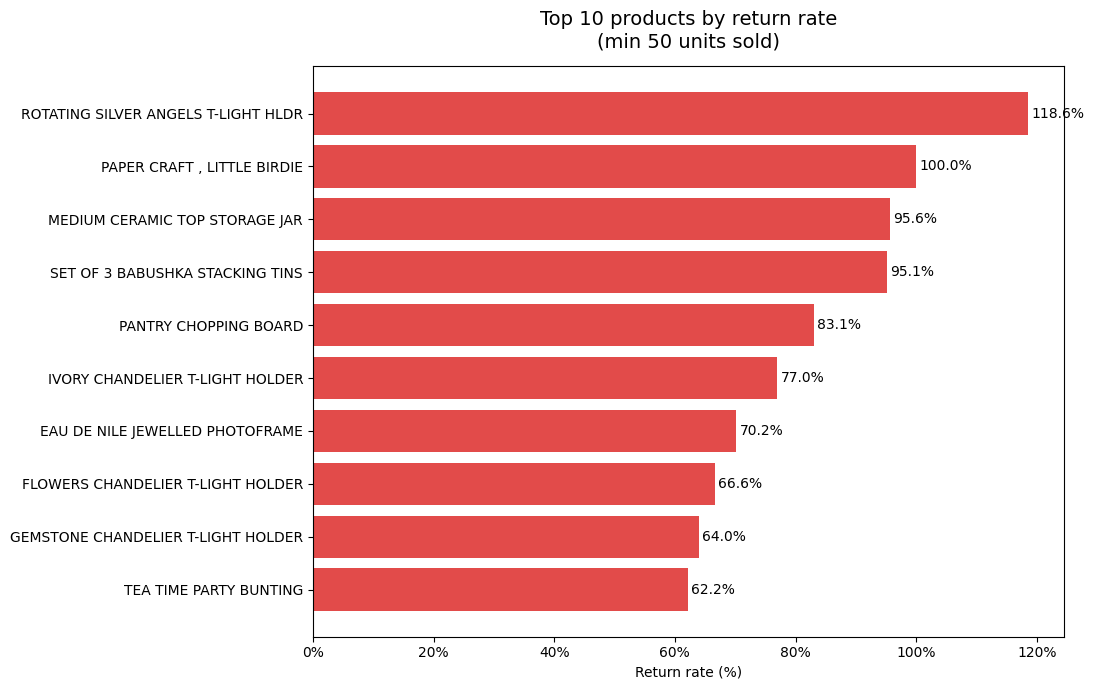

Chart saved!


In [5]:
fig, ax = plt.subplots(figsize=(11, 7))

labels = [str(d)[:40] + '...' if len(str(d)) > 40 else str(d)
          for d in high_return['Description']]

bars = ax.barh(labels[::-1], high_return['Return_Rate'][::-1],
               color='#E24B4A', edgecolor='none')

ax.set_title('Top 10 products by return rate\n(min 50 units sold)',
             fontsize=14, pad=14)
ax.set_xlabel('Return rate (%)')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for bar, val in zip(bars, high_return['Return_Rate'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/return_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
# Sort products by revenue descending
pareto = product_revenue.sort_values('Total_Revenue', ascending=False).copy()
pareto['Cumulative_Revenue'] = pareto['Total_Revenue'].cumsum()
pareto['Cumulative_Pct'] = (
    pareto['Cumulative_Revenue'] / pareto['Total_Revenue'].sum() * 100
)
pareto['Product_Rank'] = range(1, len(pareto) + 1)
pareto['Product_Pct'] = pareto['Product_Rank'] / len(pareto) * 100

# Find the 80% threshold
threshold_80 = pareto[pareto['Cumulative_Pct'] >= 80].iloc[0]
print(f"Total unique products: {len(pareto):,}")
print(f"\n80% of revenue comes from:")
print(f"  {threshold_80['Product_Rank']:,} products")
print(f"  = {threshold_80['Product_Pct']:.1f}% of all products")
print(f"\nBottom 50% of products generate only:")
bottom_50_rev = pareto[pareto['Product_Pct'] >= 50]['Total_Revenue'].sum()
print(f"  £{bottom_50_rev:,.0f} ({bottom_50_rev/pareto['Total_Revenue'].sum()*100:.1f}% of revenue)")

Total unique products: 3,897

80% of revenue comes from:
  811 products
  = 20.8% of all products

Bottom 50% of products generate only:
  £331,596 (3.7% of revenue)


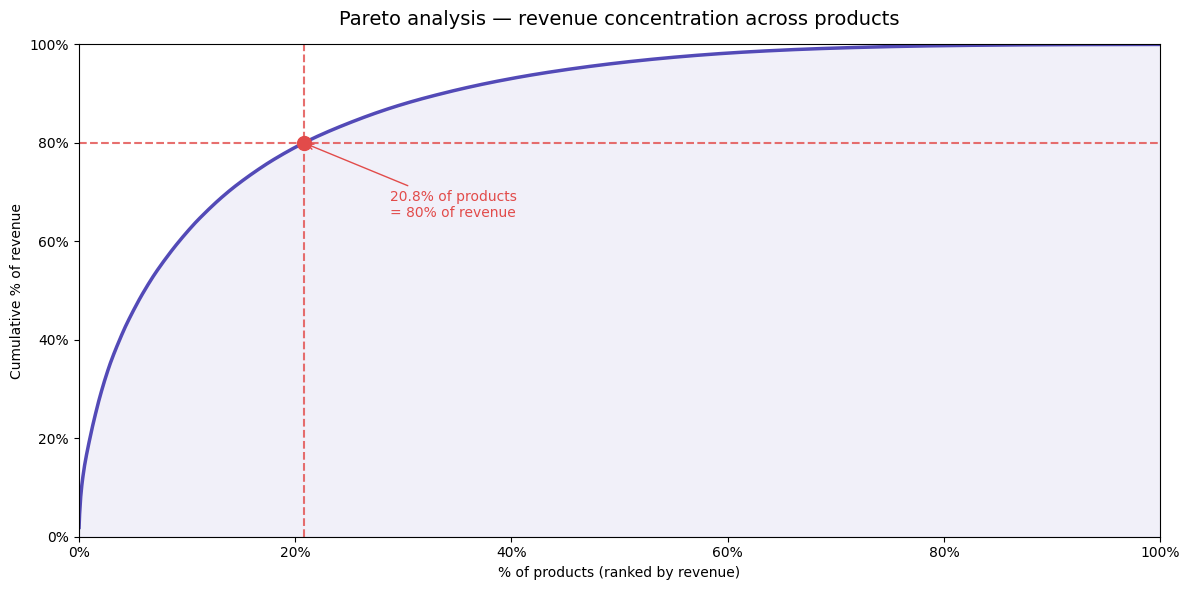

Chart saved!


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pareto['Product_Pct'], pareto['Cumulative_Pct'],
        color='#534AB7', linewidth=2.5)
ax.fill_between(pareto['Product_Pct'], pareto['Cumulative_Pct'],
                alpha=0.08, color='#534AB7')

# 80% reference lines
ax.axhline(y=80, color='#E24B4A', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(x=threshold_80['Product_Pct'], color='#E24B4A',
           linestyle='--', linewidth=1.5, alpha=0.8)
ax.plot(threshold_80['Product_Pct'], 80, 'o',
        color='#E24B4A', markersize=10, zorder=5)
ax.annotate(f"{threshold_80['Product_Pct']:.1f}% of products\n= 80% of revenue",
            xy=(threshold_80['Product_Pct'], 80),
            xytext=(threshold_80['Product_Pct'] + 8, 65),
            fontsize=10, color='#E24B4A',
            arrowprops=dict(arrowstyle='->', color='#E24B4A'))

ax.set_title('Pareto analysis — revenue concentration across products',
             fontsize=14, pad=14)
ax.set_xlabel('% of products (ranked by revenue)')
ax.set_ylabel('Cumulative % of revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../outputs/charts/pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
top_product = product_revenue.iloc[0]
top10_rev = product_revenue.head(10)['Total_Revenue'].sum()
total_rev = product_revenue['Total_Revenue'].sum()

print("=" * 55)
print("KEY FINDINGS — PRODUCT ANALYSIS")
print("=" * 55)
print(f"Total unique products:     {len(product_revenue):,}")
print(f"Top product:               {top_product['Description'][:35]}")
print(f"Top product revenue:       £{top_product['Total_Revenue']:,.0f}")
print(f"Top 10 products revenue:   £{top10_rev:,.0f} ({top10_rev/total_rev*100:.1f}% of total)")
print(f"80% revenue threshold:     top {threshold_80['Product_Pct']:.1f}% of products")
print(f"Highest return rate:       {high_return.iloc[0]['Description'][:35]}")
print(f"Return rate:               {high_return.iloc[0]['Return_Rate']:.1f}%")
print("=" * 55)

KEY FINDINGS — PRODUCT ANALYSIS
Total unique products:     3,897
Top product:               PAPER CRAFT , LITTLE BIRDIE
Top product revenue:       £168,470
Top 10 products revenue:   £886,503 (9.9% of total)
80% revenue threshold:     top 20.8% of products
Highest return rate:       ROTATING SILVER ANGELS T-LIGHT HLDR
Return rate:               118.6%
